In [1]:
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import os
import sys
import scipy
import matplotlib
from matplotlib import rcParams
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all" # to show output from all the lines in a cells
pd.set_option('display.max_column',None) # display all the columns in pandas
pd.options.display.max_rows = 100
rcParams['pdf.fonttype'] = 42
sc.settings.figdir = './figures/markers/'
sc.settings.set_figure_params(dpi = 150, color_map = 'RdPu', dpi_save = 600, vector_friendly = True, format = 'pdf')

In [2]:
def Barplot(which_var, adata, var='clusters', height=3, color = False):
    plotdata = pd.crosstab(adata.obs[var], adata.obs[which_var], normalize='index') * 100
    if 'category' in plotdata.index.dtype.name:
        plotdata.index.reorder_categories(adata.obs[var].cat.categories[::-1])

    if not color:
        ax1 = plotdata.plot.barh(stacked = True, edgecolor = 'none', zorder = 3, figsize = (6,height), fontsize = 14, grid = False)
    else:
        ax1 = plotdata.plot.barh(stacked = True, edgecolor = 'none', zorder = 3, figsize = (6,height), fontsize = 14, grid = False, color = color)
    ax1.set_title(which_var+' %')
    ax1.set_ylabel(var)
    horiz_offset = 1
    vert_offset = 1.
    ax1 = ax1.legend(bbox_to_anchor = (horiz_offset, vert_offset))
#     ax1.figure.savefig(str(sc.settings.figdir)+'/barplot_'+var+'_proportions_'+which_var+'.pdf', bbox_inches='tight',
#                        dpi=300, orientation='landscape', format= 'pdf', optimize=True)

In [3]:
cd F:\PROJECTS\PROJECT_HUMAN_FETAL_COCHLEAE\WORKPLACE\R\sc_pipeline\

F:\PROJECTS\PROJECT_HUMAN_FETAL_COCHLEAE\WORKPLACE\R\sc_pipeline


G:\Miniconda3\envs\omicverse\lib\site-packages\IPython\core\magics\osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [4]:
data_dir = '/PROJECTS/PROJECT_HUMAN_FETAL_COCHLEAE/WORKPLACE/R/sc_pipeline/'
meta = pd.read_csv(data_dir+'metadata.csv',index_col=0)
meta

,sample_id,donor,gw,gender,10xKit,sequencing,dataset,species
sample,,,,,,,,
9.5gw,gw9,not_provided_1,9.0,female,SC3,snRNA-seq,public,Homo sapiens
11.2gw,gw11,not_provided_2,11.0,male,SC3,snRNA-seq,public,Homo sapiens
14+3gw,gw14,F20240701,14.0,male,SC3,snRNA-seq,in-house,Homo sapiens
15gw,gw15,not_provided_3,15.0,female,SC3,scRNA-seq,public,Homo sapiens
16+4gw,gw16,F20241018,16.0,male,SC3,snRNA-seq,in-house,Homo sapiens
17+2gw,gw17_1,F20220807,17.0,male,SC3,snRNA-seq,in-house,Homo sapiens
17+3gw,gw17_2,F20240928,17.0,female,SC3,snRNA-seq,in-house,Homo sapiens
17gw,gw17_3,not_provided_4,17.0,male,SC3,scRNA-seq,public,Homo sapiens
18+3gw,gw18,F20220806,18.0,male,SC3,snRNA-seq,in-house,Homo sapiens


In [5]:
adata = sc.read(data_dir + 'human_cochlea_annotation.h5ad')

In [6]:
adata

AnnData object with n_obs × n_vars = 82533 × 13994
    obs: 'batch', 'CellID', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'leiden', 'louvain', 'cell_type', 'n_genes', 'sample', 'sample_id', 'donor', 'gw', 'gender', '10xKit', 'sequencing', 'dataset', 'percent_mito', 'n_counts', 'nCount_RNA', 'nFeature_RNA', 'leiden_R', 'low_ncounts', 'high_mito', 'low_ncounts_high_mito', 'S_score', 'G2M_score', 'phase', 'scrublet_score', 'scrublet_cluster_score', 'zscore', 'bh_pval', 'bonf_pval', 'is_doublet', 'leiden_res1.0', 'is_doublet_scrub', 'leiden_res1.1', 'leiden_res4.0', 'leiden_res2.0', '_scvi_batch', '_scvi_labels', 'leiden_scanvi_2.0', 'leiden_scanvi_3.0', 'leiden_scanvi_4.0', 'cell_type_final'
    var: 'Gene', 'mt', 'gene_ids-0', 'feature_types-0', 'n_cells_by_counts-0', 'mean_counts-0', 'pct_dropout_by_counts-0', 'total_counts-0', 'highly_variable-0', 'means-0', 'dispersions-0', 'dispersions_norm-0', 'n_cells-0', 'gene_ids-1', 'feature_types-1', 'n_cells_by_co

In [63]:
# %load _markers.py
from collections import defaultdict
import numpy as np
import pandas as pd
import scipy.sparse as sp
from sklearn.preprocessing import normalize
import anndata
import scanpy as sc


def calc_marker_stats(ad, groupby, genes=None, use_rep='raw', inplace=False, partial=False):
    if ad.obs[groupby].dtype.name != 'category':
        raise ValueError('"%s" is not categorical' % groupby)
    n_grp = ad.obs[groupby].cat.categories.size
    if n_grp < 2:
        raise ValueError('"%s" must contain at least 2 categories' % groupby)
    if use_rep == 'raw':
        X = ad.raw.X
        var_names = ad.raw.var_names.values
    else:
        X = ad.X
        var_names = ad.var_names.values
    if not sp.issparse(X):
        X = sp.csr_matrix(X)
    if genes:
        v_idx = var_names.isin(genes)
        X = X[:, v_idx]
        var_names = var_names[v_idx]

    X = normalize(X, norm='max', axis=0)
    k_nonzero = X.sum(axis=0).A1 > 0
    X = X[:, np.where(k_nonzero)[0]]
    var_names = var_names[k_nonzero]

    n_var = var_names.size
    x = np.arange(n_var)

    grp_indices = {k: g.index.values for k, g in ad.obs.reset_index().groupby(groupby, sort=False)}
    
    frac_df = pd.DataFrame({k: (X[idx, :]>0).mean(axis=0).A1 for k, idx in grp_indices.items()}, index=var_names)
    mean_df = pd.DataFrame({k: X[idx, :].mean(axis=0).A1 for k, idx in grp_indices.items()}, index=var_names)

    if partial:
        stats_df = None
    else:
        frac_order = np.apply_along_axis(np.argsort, axis=1, arr=frac_df.values)
        y1 = frac_order[:, n_grp-1]
        y2 = frac_order[:, n_grp-2]
        y3 = frac_order[:, n_grp-3] if n_grp > 2 else y2
        top_frac_grps = frac_df.columns.values[y1]
        top_fracs = frac_df.values[x, y1]
        frac_diffs = top_fracs - frac_df.values[x, y2]
        max_frac_diffs = top_fracs - frac_df.values[x, y3]
 
        mean_order = np.apply_along_axis(np.argsort, axis=1, arr=mean_df.values)
        y1 = mean_order[:, n_grp-1]
        y2 = mean_order[:, n_grp-2]
        y3 = mean_order[:, n_grp-3] if n_grp > 2 else y2
        top_mean_grps = mean_df.columns.values[y1]
        top_means = mean_df.values[x, y1]
        mean_diffs = top_means - mean_df.values[x, y2]
        max_mean_diffs = top_means - mean_df.values[x, y3]

        stats_df = pd.DataFrame({
            'top_frac_group': top_frac_grps, 'top_frac': top_fracs, 'frac_diff': frac_diffs, 'max_frac_diff': max_frac_diffs,
            'top_mean_group': top_mean_grps, 'top_mean': top_means, 'mean_diff': mean_diffs, 'max_mean_diff': max_mean_diffs
        }, index=var_names)
        stats_df['top_frac_group'] = stats_df['top_frac_group'].astype('category')
        stats_df['top_frac_group'].cat.reorder_categories(list(ad.obs[groupby].cat.categories), inplace=True)

    if inplace:
        if use_rep == 'raw':
            ad.raw.varm[f'frac_{groupby}'] = frac_df
            ad.raw.varm[f'mean_{groupby}'] = mean_df
            if not partial:
                ad.raw.var = pd.concat([ad.raw.var, stats_df], axis=1)
        else:
            ad.varm[f'frac_{groupby}'] = frac_df
            ad.varm[f'mean_{groupby}'] = mean_df
            if not partial:
                ad.var = pd.concat([ad.raw.var, stats_df], axis=1)
    else:
        return frac_df, mean_df, stats_df


def filter_marker_stats(data, use_rep='raw', min_frac_diff=0.1, min_mean_diff=0.1, max_next_frac=0.9, max_next_mean=0.95, strict=False, how='or'):
    columns = ['top_frac_group', 'top_frac', 'frac_diff', 'max_frac_diff', 'top_mean_group', 'top_mean', 'mean_diff', 'max_mean_diff']
    if isinstance(data, anndata.AnnData):
        stats_df = data.raw.var[columns] if use_rep == 'raw' else data.var[columns]
    elif isinstance(data, pd.DataFrame):
        stats_df = data[columns]
    else:
        raise ValueError('Invalid input, must be an AnnData or DataFrame')
    frac_diff = stats_df.frac_diff if strict else stats_df.max_frac_diff
    mean_diff = stats_df.mean_diff if strict else stats_df.max_mean_diff
    same_group = stats_df.top_frac_group == stats_df.top_mean_group
    meet_frac_requirement = (frac_diff >= min_frac_diff) & (stats_df.top_frac - frac_diff <= max_next_frac)
    meet_mean_requirement = (mean_diff >= min_mean_diff) & (stats_df.top_mean - mean_diff <= max_next_mean)
    if how == 'or':
        filtered = stats_df.loc[same_group & (meet_frac_requirement | meet_mean_requirement)]
    else:
        filtered = stats_df.loc[same_group & (meet_frac_requirement & meet_mean_requirement)]
    if strict:
        filtered = filtered.sort_values(['top_frac_group', 'mean_diff', 'frac_diff'], ascending=[True, False, False])
    else:
        filtered = filtered.sort_values(['top_frac_group', 'mean_diff', 'frac_diff'], ascending=[True, False, False])
    filtered['top_frac_group'] = filtered['top_frac_group'].astype('category')
    filtered['top_frac_group'].cat.reorder_categories(list(stats_df['top_frac_group'].cat.categories), inplace=True)
    return filtered


def plot_markers(
    adata: anndata.AnnData,
    groupby: str,
    mks: pd.DataFrame,
    n_genes: int = 5,
    kind: str = 'dotplot',
    remove_genes: list = [],
    **kwargs
):
    df = mks.reset_index()[['index', 'top_frac_group']].rename(columns={'index': 'gene', 'top_frac_group': 'cluster'})
    var_tb = adata.raw.var if kwargs.get('use_raw', None) == True or adata.raw else adata.var
    remove_gene_set = set()
    for g_cat in remove_genes:
        if g_cat in var_tb.columns:
            remove_gene_set |= set(var_tb.index[var_tb[g_cat].values])
    df = df[~df.gene.isin(list(remove_gene_set))].copy()
    df1 = df.groupby('cluster').head(n_genes)
    mks_dict = defaultdict(list)
    for c, g in zip(df1.cluster, df1.gene):
        mks_dict[c].append(g)
    func = getattr(sc.pl, kind)
    if sc.__version__.startswith('1.4'):
        return func(adata, df1.gene.to_list(), groupby=groupby, **kwargs)
    else:
        return func(adata, mks_dict, groupby=groupby, **kwargs)


In [99]:
from collections import defaultdict
import numpy as np
import pandas as pd
import scipy.sparse as sp
from sklearn.preprocessing import normalize
import anndata
import scanpy as sc


def calc_marker_stats(ad, groupby, genes=None, use_rep='raw', inplace=False, partial=False):
    if ad.obs[groupby].dtype.name != 'category':
        raise ValueError('"%s" is not categorical' % groupby)
    n_grp = ad.obs[groupby].cat.categories.size
    if n_grp < 2:
        raise ValueError('"%s" must contain at least 2 categories' % groupby)
    if use_rep == 'raw':
        X = ad.raw.X
        var_names = ad.raw.var_names.values
    else:
        X = ad.X
        var_names = ad.var_names.values
    if not sp.issparse(X):
        X = sp.csr_matrix(X)
    if genes:
        v_idx = var_names.isin(genes)
        X = X[:, v_idx]
        var_names = var_names[v_idx]

    X = normalize(X, norm='max', axis=0)
    k_nonzero = X.sum(axis=0).A1 > 0
    X = X[:, np.where(k_nonzero)[0]]
    var_names = var_names[k_nonzero]

    n_var = var_names.size
    x = np.arange(n_var)

    grp_indices = {k: g.index.values for k, g in ad.obs.reset_index().groupby(groupby, sort=False)}
    
    frac_df = pd.DataFrame({k: (X[idx, :]>0).mean(axis=0).A1 for k, idx in grp_indices.items()}, index=var_names)
    mean_df = pd.DataFrame({k: X[idx, :].mean(axis=0).A1 for k, idx in grp_indices.items()}, index=var_names)

    if partial:
        stats_df = None
    else:
        frac_order = np.apply_along_axis(np.argsort, axis=1, arr=frac_df.values)
        y1 = frac_order[:, n_grp-1]
        y2 = frac_order[:, n_grp-2]
        y3 = frac_order[:, n_grp-3] if n_grp > 2 else y2
        top_frac_grps = frac_df.columns.values[y1]
        top_fracs = frac_df.values[x, y1]
        frac_diffs = top_fracs - frac_df.values[x, y2]
        max_frac_diffs = top_fracs - frac_df.values[x, y3]
 
        mean_order = np.apply_along_axis(np.argsort, axis=1, arr=mean_df.values)
        y1 = mean_order[:, n_grp-1]
        y2 = mean_order[:, n_grp-2]
        y3 = mean_order[:, n_grp-3] if n_grp > 2 else y2
        top_mean_grps = mean_df.columns.values[y1]
        top_means = mean_df.values[x, y1]
        mean_diffs = top_means - mean_df.values[x, y2]
        max_mean_diffs = top_means - mean_df.values[x, y3]

        stats_df = pd.DataFrame({
            'top_frac_group': top_frac_grps, 'top_frac': top_fracs, 'frac_diff': frac_diffs, 'max_frac_diff': max_frac_diffs,
            'top_mean_group': top_mean_grps, 'top_mean': top_means, 'mean_diff': mean_diffs, 'max_mean_diff': max_mean_diffs
        }, index=var_names)
        stats_df['top_frac_group'] = stats_df['top_frac_group'].astype('category')
        stats_df['top_frac_group'].cat.reorder_categories(list(ad.obs[groupby].cat.categories), inplace=True)

    if inplace:
        if use_rep == 'raw':
            ad.raw.varm[f'frac_{groupby}'] = frac_df
            ad.raw.varm[f'mean_{groupby}'] = mean_df
            if not partial:
                ad.raw.var = pd.concat([ad.raw.var, stats_df], axis=1)
        else:
            ad.varm[f'frac_{groupby}'] = frac_df
            ad.varm[f'mean_{groupby}'] = mean_df
            if not partial:
                ad.var = pd.concat([ad.raw.var, stats_df], axis=1)
    else:
        return stats_df
#n_grp = ad.obs[groupby].cat.categories.size

In [100]:
stats_df=calc_marker_stats(adata, groupby='cell_type_final', genes=None, use_rep=False, inplace=False, partial=False)

C:\Users\Dell\AppData\Local\Temp\ipykernel_35680\3645156511.py:68: FutureWarning: The `inplace` parameter in pandas.Categorical.reorder_categories is deprecated and will be removed in a future version. Reordering categories will always return a new Categorical object.
  stats_df['top_frac_group'].cat.reorder_categories(list(ad.obs[groupby].cat.categories), inplace=True)


In [101]:
stats_df

,top_frac_group,top_frac,frac_diff,max_frac_diff,top_mean_group,top_mean,mean_diff,max_mean_diff
LINC00115,Spindle/Root_cells,0.037383,0.002295,0.007971,CoE_Medial,0.012791,0.000223,0.001060
SAMD11,VGNs,0.290323,0.005804,0.115600,pre-Osteoblasts,0.106835,0.041140,0.046824
NOC2L,Vestibular_HCs,0.280702,0.032294,0.052546,Vestibular_Dark_cells,0.079320,0.011734,0.014391
KLHL17,SGNs,0.039910,0.006797,0.007652,Vestibular_Roof_cells,0.015140,0.002012,0.002078
HES4,Smooth_Muscle_Cells,0.446809,0.055164,0.095865,Smooth_Muscle_Cells,0.179359,0.022393,0.057410
...,...,...,...,...,...,...,...,...
MT-ND4L,SCs,0.685535,0.142094,0.153223,Intermediate_stria,0.193377,0.005215,0.009464
MT-ND4,SCs,0.974843,0.007101,0.189712,SCs,0.685263,0.193965,0.298259
MT-ND5,SCs,0.974843,0.208954,0.221915,SCs,0.424163,0.106039,0.107653
MT-ND6,SCs,0.371069,0.026267,0.045791,Fibrocytes,0.177505,0.030452,0.058190


In [102]:
pd.DataFrame(stats_df).to_csv('markers_pre.csv')

In [103]:
stats_df = pd.read_csv('markers_pre.csv', index_col=0)

In [107]:
adata.varm["stats_df"] = stats_df.to_numpy()

In [108]:
def filter_marker_stats(data, use_rep='raw', min_frac_diff=0.1, min_mean_diff=0.1, max_next_frac=0.9, max_next_mean=0.95, strict=False, how='or'):
    columns = ['top_frac_group', 'top_frac', 'frac_diff', 'max_frac_diff', 'top_mean_group', 'top_mean', 'mean_diff', 'max_mean_diff']
    if isinstance(data, anndata.AnnData):
        stats_df = data.raw.var[columns] if use_rep == 'raw' else data.var[columns]
    elif isinstance(data, pd.DataFrame):
        stats_df = data[columns]
    else:
        raise ValueError('Invalid input, must be an AnnData or DataFrame')
    frac_diff = stats_df.frac_diff if strict else stats_df.max_frac_diff
    mean_diff = stats_df.mean_diff if strict else stats_df.max_mean_diff
    same_group = stats_df.top_frac_group == stats_df.top_mean_group
    meet_frac_requirement = (frac_diff >= min_frac_diff) & (stats_df.top_frac - frac_diff <= max_next_frac)
    meet_mean_requirement = (mean_diff >= min_mean_diff) & (stats_df.top_mean - mean_diff <= max_next_mean)
    if how == 'or':
        filtered = stats_df.loc[same_group & (meet_frac_requirement | meet_mean_requirement)]
    else:
        filtered = stats_df.loc[same_group & (meet_frac_requirement & meet_mean_requirement)]
    if strict:
        filtered = filtered.sort_values(['top_frac_group', 'mean_diff', 'frac_diff'], ascending=[True, False, False])
    else:
        filtered = filtered.sort_values(['top_frac_group', 'mean_diff', 'frac_diff'], ascending=[True, False, False])
    filtered['top_frac_group'] = filtered['top_frac_group'].astype('category')
    filtered['top_frac_group'].cat.reorder_categories(list(stats_df['top_frac_group'].cat.categories), inplace=True)
    return filtered

In [109]:
adata3=filter_marker_stats(adata, use_rep=False, min_frac_diff=0.1, min_mean_diff=0.1, max_next_frac=0.9, max_next_mean=0.95, strict=False, how='or')

C:\Users\Dell\AppData\Local\Temp\ipykernel_35680\376069003.py:23: FutureWarning: The `inplace` parameter in pandas.Categorical.reorder_categories is deprecated and will be removed in a future version. Reordering categories will always return a new Categorical object.
  filtered['top_frac_group'].cat.reorder_categories(list(stats_df['top_frac_group'].cat.categories), inplace=True)


In [110]:
adata3

,top_frac_group,top_frac,frac_diff,max_frac_diff,top_mean_group,top_mean,mean_diff,max_mean_diff
CCDC73,Basal_stria,0.447106,0.253904,0.344302,Basal_stria,0.246443,0.163979,0.229366
KCNIP1,Basal_stria,0.564870,0.016483,0.021011,Basal_stria,0.286050,0.080618,0.118880
OBSCN,Basal_stria,0.590818,0.066668,0.113111,Basal_stria,0.327535,0.078633,0.150506
ADARB2,Basal_stria,0.654691,0.071506,0.113698,Basal_stria,0.349234,0.076198,0.084802
RBM47,Basal_stria,0.898204,0.053839,0.072573,Basal_stria,0.476710,0.064331,0.109995
...,...,...,...,...,...,...,...,...
ETV1,pre-Osteocytes,0.620690,0.068491,0.155572,pre-Osteocytes,0.228420,0.008889,0.047492
NOTCH2,pre-Osteocytes,0.839080,0.075295,0.138941,pre-Osteocytes,0.312373,0.008254,0.021972
PRICKLE1,pre-Osteocytes,0.758621,0.090095,0.205365,pre-Osteocytes,0.315797,0.007915,0.092349
EPB41L2,pre-Osteocytes,0.954023,0.136729,0.177740,pre-Osteocytes,0.399382,0.006958,0.041020


In [127]:
pd.DataFrame(adata3).to_csv('markers_final.csv')

In [125]:
def plot_markers(
    adata: anndata.AnnData,
    groupby: str,
    mks: pd.DataFrame,
    n_genes: int = 5,
    kind: str = 'dotplot',
    remove_genes: list = [],
    **kwargs
):
    df = mks.reset_index()[['index', 'top_frac_group']].rename(columns={'index': 'gene', 'top_frac_group': 'cluster'})
    var_tb = adata.raw.var if kwargs.get('use_raw', None) == True or adata.raw else adata.var
    remove_gene_set = set()
    for g_cat in remove_genes:
        if g_cat in var_tb.columns:
            remove_gene_set |= set(var_tb.index[var_tb[g_cat].values])
    df = df[~df.gene.isin(list(remove_gene_set))].copy()
    df1 = df.groupby('cluster').head(n_genes)
    mks_dict = defaultdict(list)
    for c, g in zip(df1.cluster, df1.gene):
        mks_dict[c].append(g)
    func = getattr(sc.pl, kind)
    if sc.__version__.startswith('1.4'):
        return func(adata, df1.gene.to_list(), groupby=groupby, **kwargs)
    else:
        return func(adata, mks_dict, groupby=groupby, **kwargs)

In [126]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
plot_markers(
    adata,
    groupby='cell_type_final',
    mks=pd.DataFrame(adata3),
    n_genes= 3,
    kind = 'dotplot',save="_markers_human_cochlea.pdf",
    #remove_genes: list = [],
    #**kwargs
)

meta NOT subset; don't know how to subset; dropped


In [7]:
marker_genes =['TMC1','MYO7A','SNAP25','TUBB3','GATA3','LGR5','LGR6','LGR4','F2RL1']

meta NOT subset; don't know how to subset; dropped


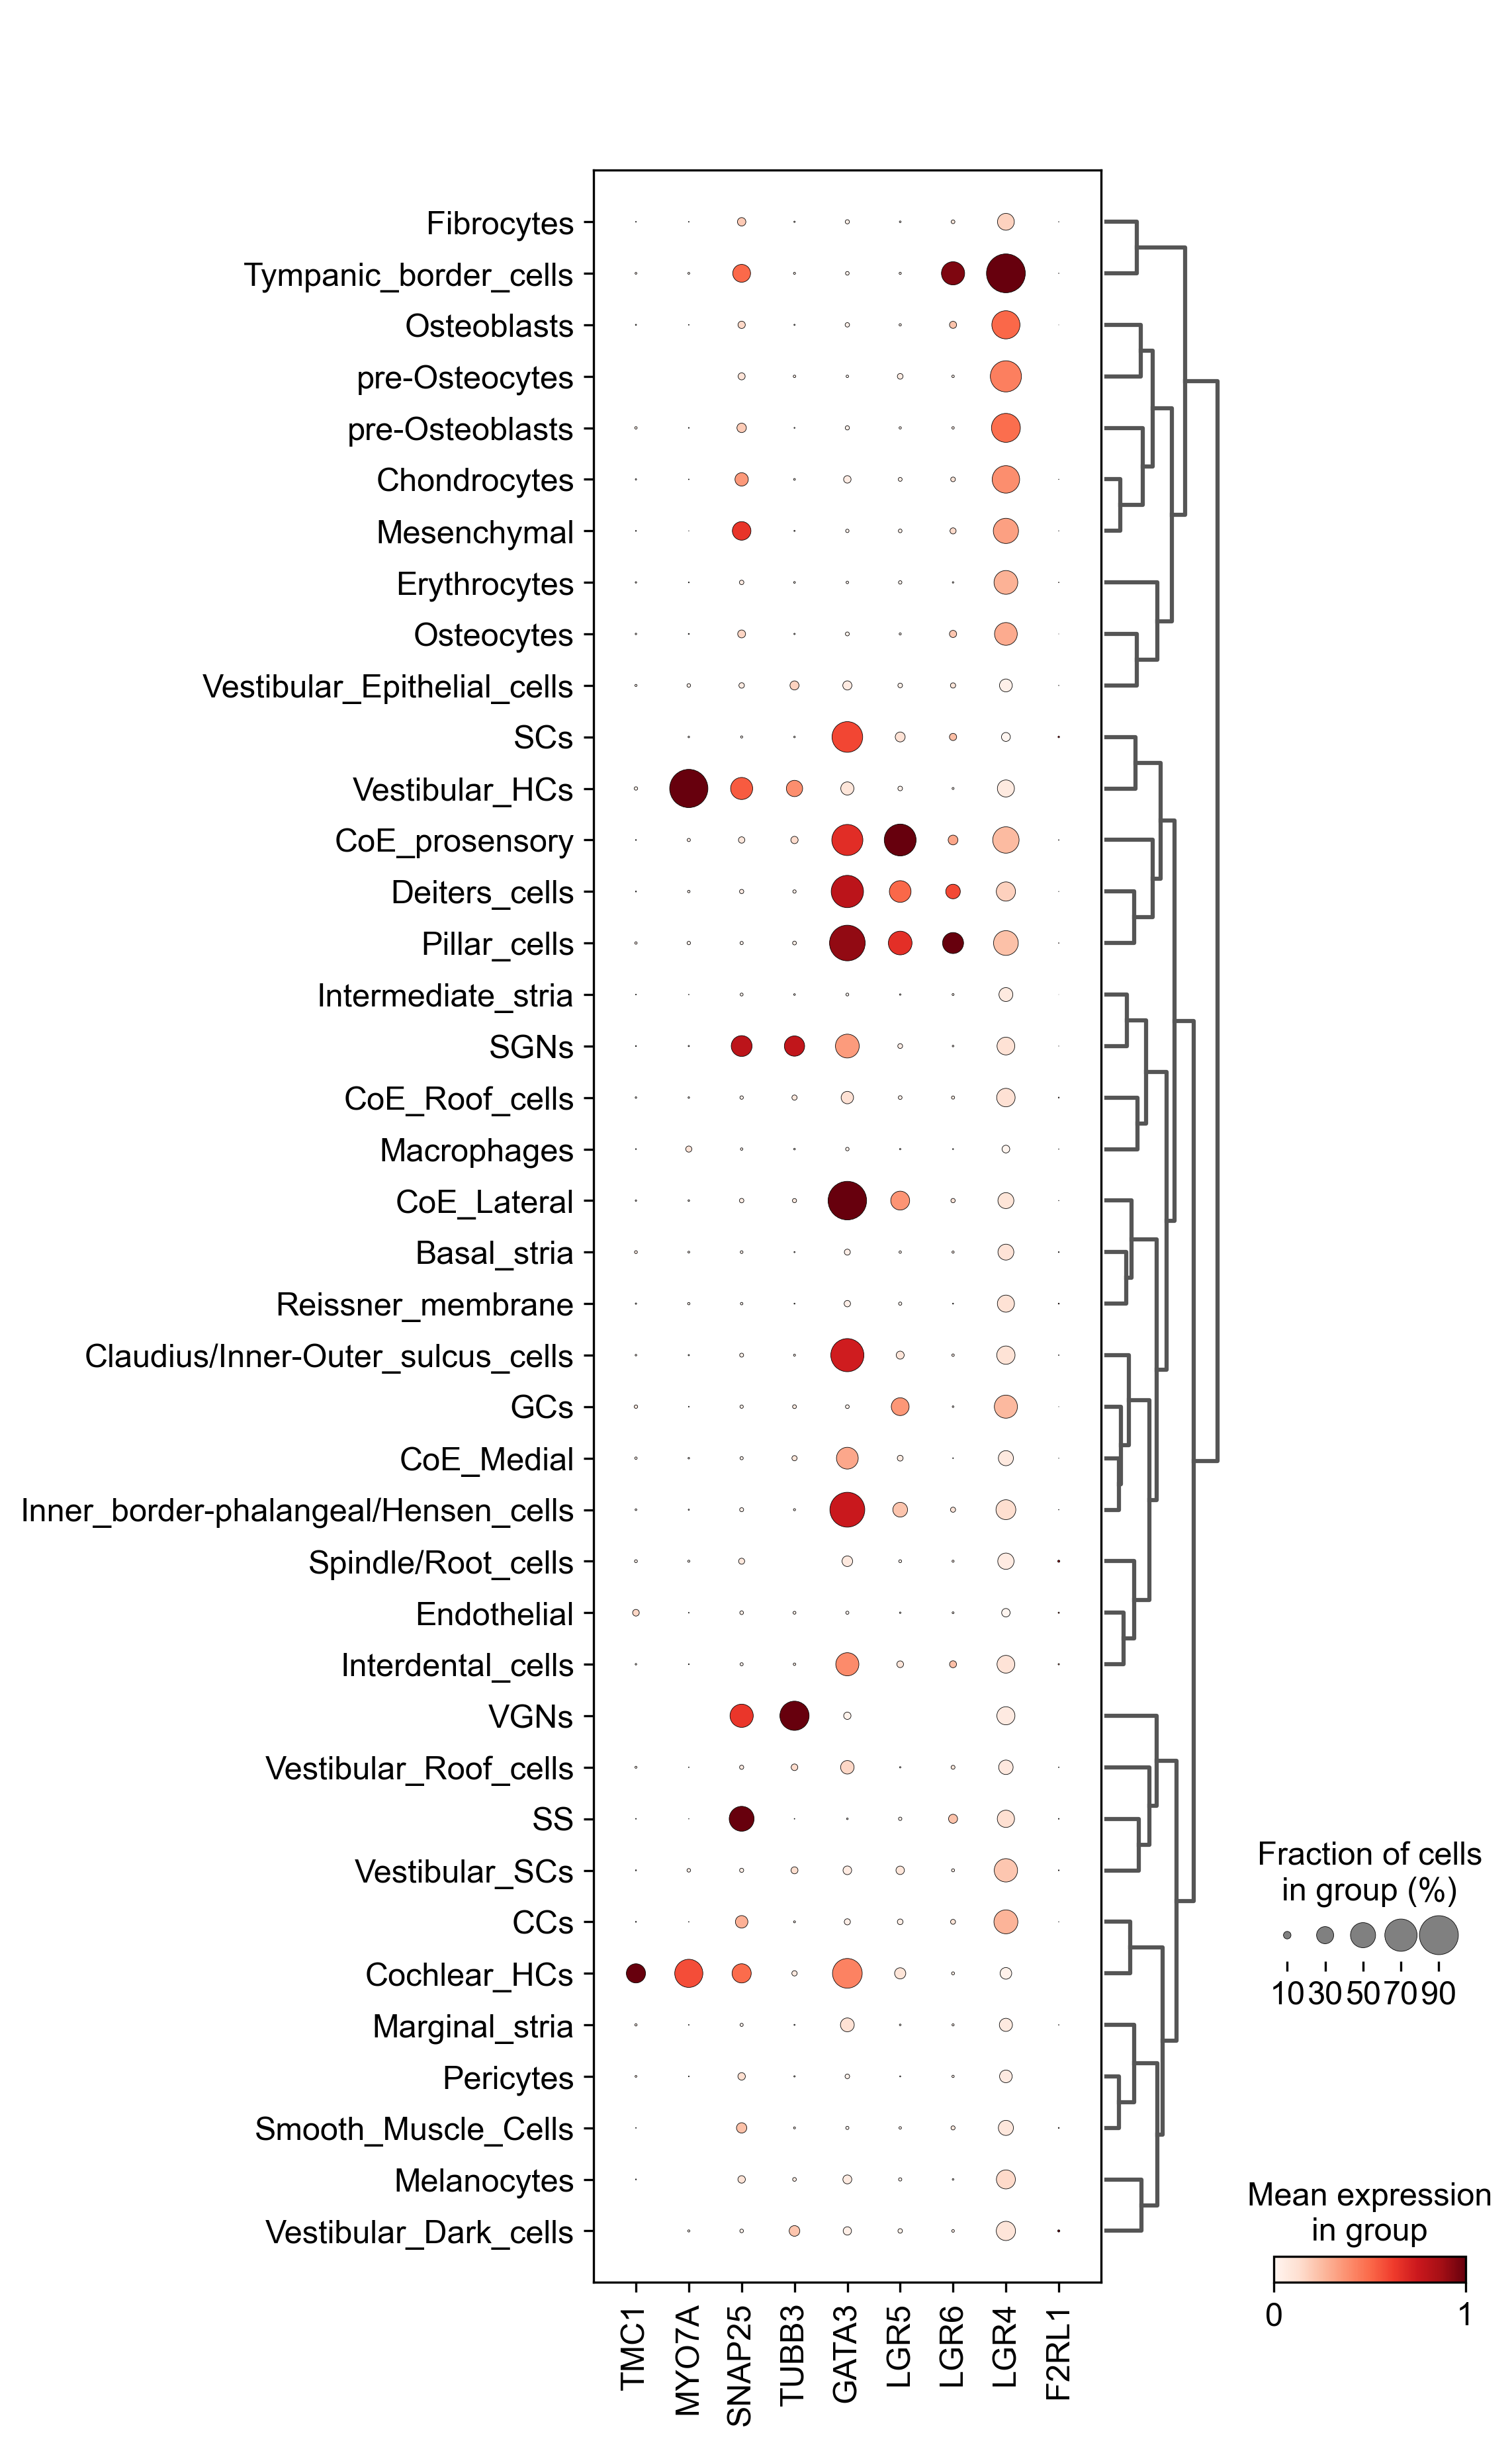

In [8]:
sc.set_figure_params(figsize=(4,4),frameon=False,dpi=150,dpi_save=600)
sc.pl.dotplot(
    adata,
    groupby="cell_type_final",
    var_names=marker_genes,
   dendrogram=True,
    standard_scale="var",  # standard scale: normalize each gene to range from 0 to 1
    save="cochlea-cell_type_human_gpcr.pdf"
)